# Signal Processing and FFT

---

### What you will learn

| Module | Topics |
|--------|--------|
| 1 | Discrete Fourier Transform — theory and implementation |
| 2 | Windowing and spectral leakage |
| 3 | Vibration Analysis Automation Scenario |

---

In [2]:
# ── Global imports (run this cell first) ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.fft import fft, ifft, fftfreq, fftshift

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
    'font.size': 11,
})
rng = np.random.default_rng(42)   # reproducible random numbers
print('All imports OK')

All imports OK


---
## 1. Discrete Fourier Transform

The **Discrete Fourier Transform** converts $N$ equally-spaced time-domain samples into $N$ complex frequency-domain coefficients:

$$X_k = \sum_{n=0}^{N-1} x_n \, e^{-j2\pi kn/N}, \qquad k = 0, 1, \ldots, N-1$$

Key parameters:

* **Frequency resolution** $\Delta f = f_s / N$ — more samples → finer frequency bins.
* **Nyquist limit** $f_{Nyq} = f_s / 2$ — you cannot see frequencies above this.
* For a real signal, the second half of the DFT is a mirror of the first; only the first $N/2$ bins carry unique information.
* `numpy.fft.fft` implements the Cooley–Tukey **Fast Fourier Transform** (FFT) in $O(N \log N)$ — orders of magnitude faster than the $O(N^2)$ naive DFT.

**Why does this matter for vibrations?**  
Vibration signals look like noise in the time domain. Their FFT reveals discrete peaks at natural frequencies instantly.

In [9]:
# ── 1a: The naive O(N²) DFT — so you see what FFT replaces ──────────────────

def naive_dft(x):
    """Compute the DFT using the definition (slow — O(N^2))."""
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))          # column vector for broadcasting
    M = np.exp(-2j * np.pi * k * n / N)   # DFT matrix
    return M @ x

# Test signal: two sinusoids
fs = 200          # Hz
N  = 256
t  = np.arange(N) / fs
x  = 3.0 * np.sin(2*np.pi*20*t) + 1.5 * np.sin(2*np.pi*55*t)

X_naive = naive_dft(x)
X_fft   = fft(x)           # NumPy's FFT

# They must agree
print(f'Max difference |naive – FFT|: {np.max(np.abs(X_naive - X_fft)):.2e}')
print('(should be ~machine epsilon)')

Max difference |naive – FFT|: 1.13e-11
(should be ~machine epsilon)


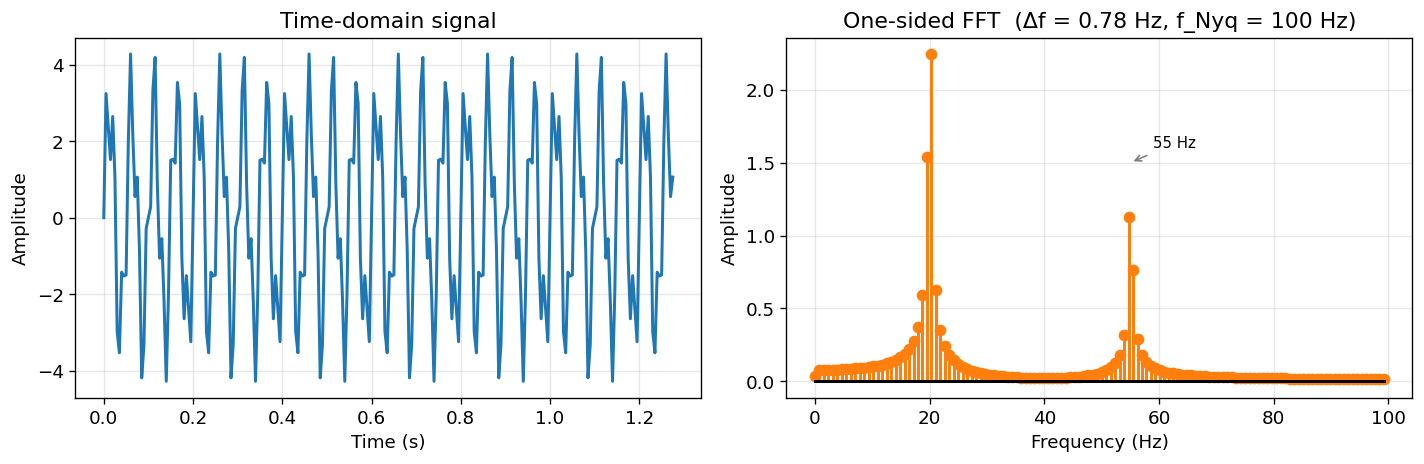

Frequency resolution Δf = fs/N = 200/256 = 0.781 Hz


In [4]:
# ── 1b: Visualise the one-sided FFT spectrum ─────────────────────────────────

freqs  = fftfreq(N, d=1/fs)          # full two-sided frequency axis
mag    = np.abs(X_fft) / N           # normalise amplitude

# One-sided: keep only positive frequencies
pos    = freqs >= 0
f_pos  = freqs[pos]
mag_1s = 2 * mag[pos]                # ×2 to conserve energy (mirror folded in)
mag_1s[0] /= 2                       # DC bin is not doubled

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, x)
axes[0].set(xlabel='Time (s)', ylabel='Amplitude', title='Time-domain signal')

axes[1].stem(f_pos, mag_1s, markerfmt='C1o', linefmt='C1-', basefmt='k-')
axes[1].set(xlabel='Frequency (Hz)', ylabel='Amplitude',
            title=f'One-sided FFT  (Δf = {fs/N:.2f} Hz, f_Nyq = {fs//2} Hz)')

# Annotate peaks
for f_peak, amp in [(20, 3.0), (55, 1.5)]:
    axes[1].annotate(f'{f_peak} Hz', xy=(f_peak, amp),
                     xytext=(f_peak+4, amp+0.1), fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()
print(f'Frequency resolution Δf = fs/N = {fs}/{N} = {fs/N:.3f} Hz')

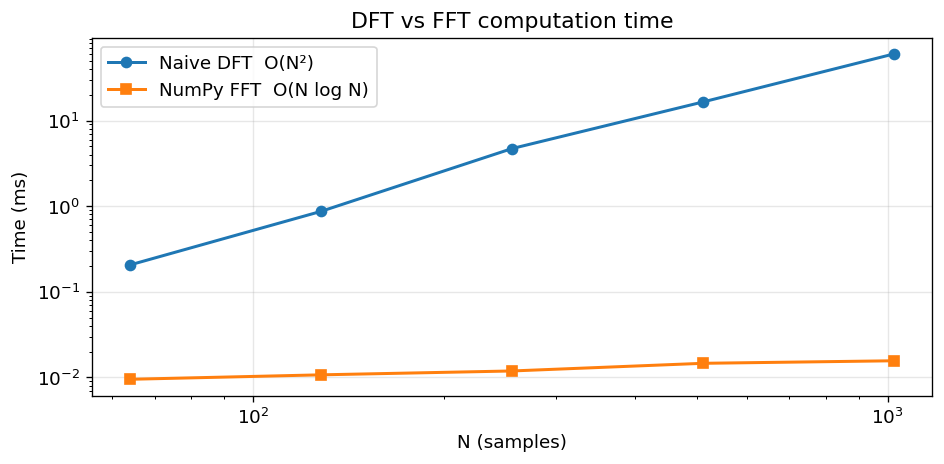

Speedup at N=1024: 3844×


In [5]:
# ── 1c: Speed comparison — naive DFT vs FFT ─────────────────────────────────
import time

sizes = [64, 128, 256, 512, 1024]
t_naive, t_fft = [], []

for n in sizes:
    sig = rng.standard_normal(n)

    t0 = time.perf_counter()
    for _ in range(20): naive_dft(sig)
    t_naive.append((time.perf_counter() - t0) / 20 * 1e3)  # ms

    t0 = time.perf_counter()
    for _ in range(500): fft(sig)
    t_fft.append((time.perf_counter() - t0) / 500 * 1e3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(sizes, t_naive, 'o-', label='Naive DFT  O(N²)')
ax.loglog(sizes, t_fft,   's-', label='NumPy FFT  O(N log N)')
ax.set(xlabel='N (samples)', ylabel='Time (ms)', title='DFT vs FFT computation time')
ax.legend()
plt.tight_layout(); plt.show()

print('Speedup at N=1024:', f'{t_naive[-1]/t_fft[-1]:.0f}×')

---
## 2. Windowing and Spectral Leakage

The FFT implicitly assumes the signal **repeats periodically**. If the last sample does not connect smoothly to the first, the DFT sees a sharp discontinuity — this smears energy across all frequency bins. This is called **spectral leakage**.

**When does leakage occur?**  
Whenever the signal frequency is not an exact integer multiple of $\Delta f$ (i.e., a non-integer number of cycles fits in the window).

**Solution: multiply by a window function $w[n]$** that tapers smoothly to zero at both ends before computing the FFT.

| Window | Main-lobe width | Side-lobe level | Use case |
|--------|-----------------|-----------------|----------|
| Rectangular (none) | Narrowest | −13 dB | Only when frequency is exactly in a bin |
| Hann | Moderate | −31 dB | General vibration work |
| Hamming | Moderate | −43 dB | Narrowband signals |
| Blackman | Wide | −58 dB | When dynamic range matters most |
| Flat-top | Widest | −93 dB | Amplitude accuracy > frequency accuracy |

> For vibration FRFs, use **Hann** (periodic) window.  
> Windowing reduces amplitude accuracy — compensate with a correction factor (e.g., Hann → ×2).

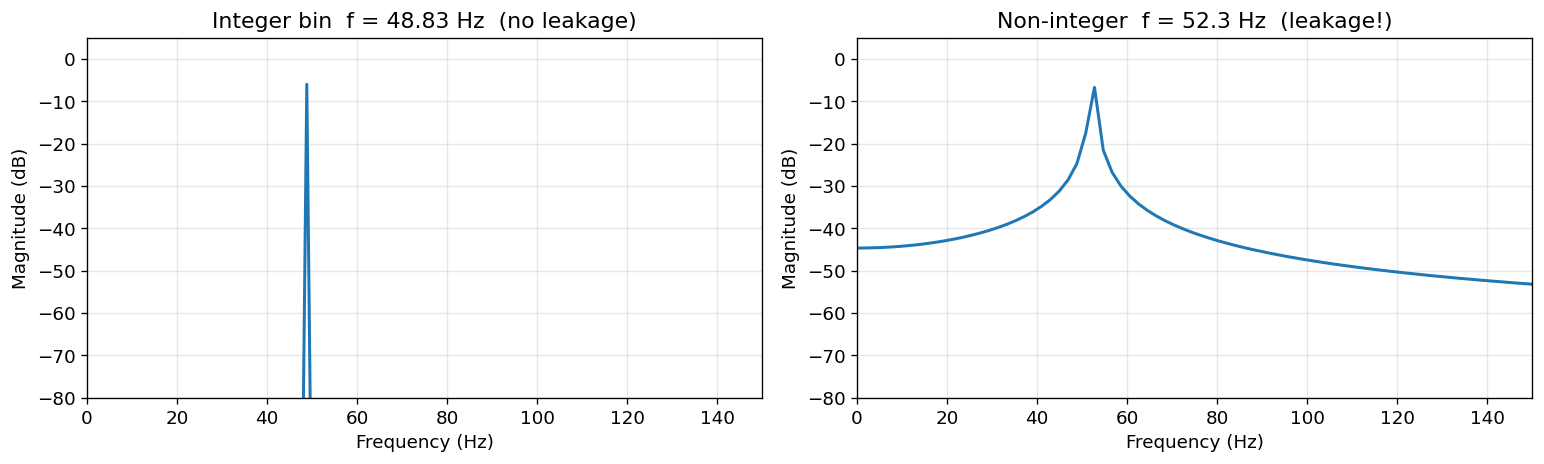

In [6]:
# ── 2a: Demonstrate leakage — integer vs non-integer cycles ──────────────────

fs = 1000.0    # Hz
N  = 512
t  = np.arange(N) / fs

f_integer    = 50.0          # exactly 25.6 cycles → bin 25 if Δf=1.95 Hz... actually:
f_integer    = fs * 25 / N   # this IS exactly in a bin
f_noninteger = 52.3          # fractional bin → leakage

x_int = np.sin(2*np.pi * f_integer    * t)
x_frac= np.sin(2*np.pi * f_noninteger * t)

def one_sided_mag(x, fs):
    N = len(x)
    X = np.abs(fft(x)) / N
    f = fftfreq(N, 1/fs)
    pos = f >= 0
    X[pos][1:] *= 2
    return f[pos], X[pos]

fi, Xi   = one_sided_mag(x_int,  fs)
ff, Xf   = one_sided_mag(x_frac, fs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, f_vals, X_vals, title in [
        (axes[0], fi, Xi, f'Integer bin  f = {f_integer:.2f} Hz  (no leakage)'),
        (axes[1], ff, Xf, f'Non-integer  f = {f_noninteger} Hz  (leakage!)')]:
    ax.plot(f_vals, 20*np.log10(np.maximum(X_vals, 1e-10)))
    ax.set(xlabel='Frequency (Hz)', ylabel='Magnitude (dB)', title=title,
           xlim=(0, 150), ylim=(-80, 5))

plt.tight_layout(); plt.show()

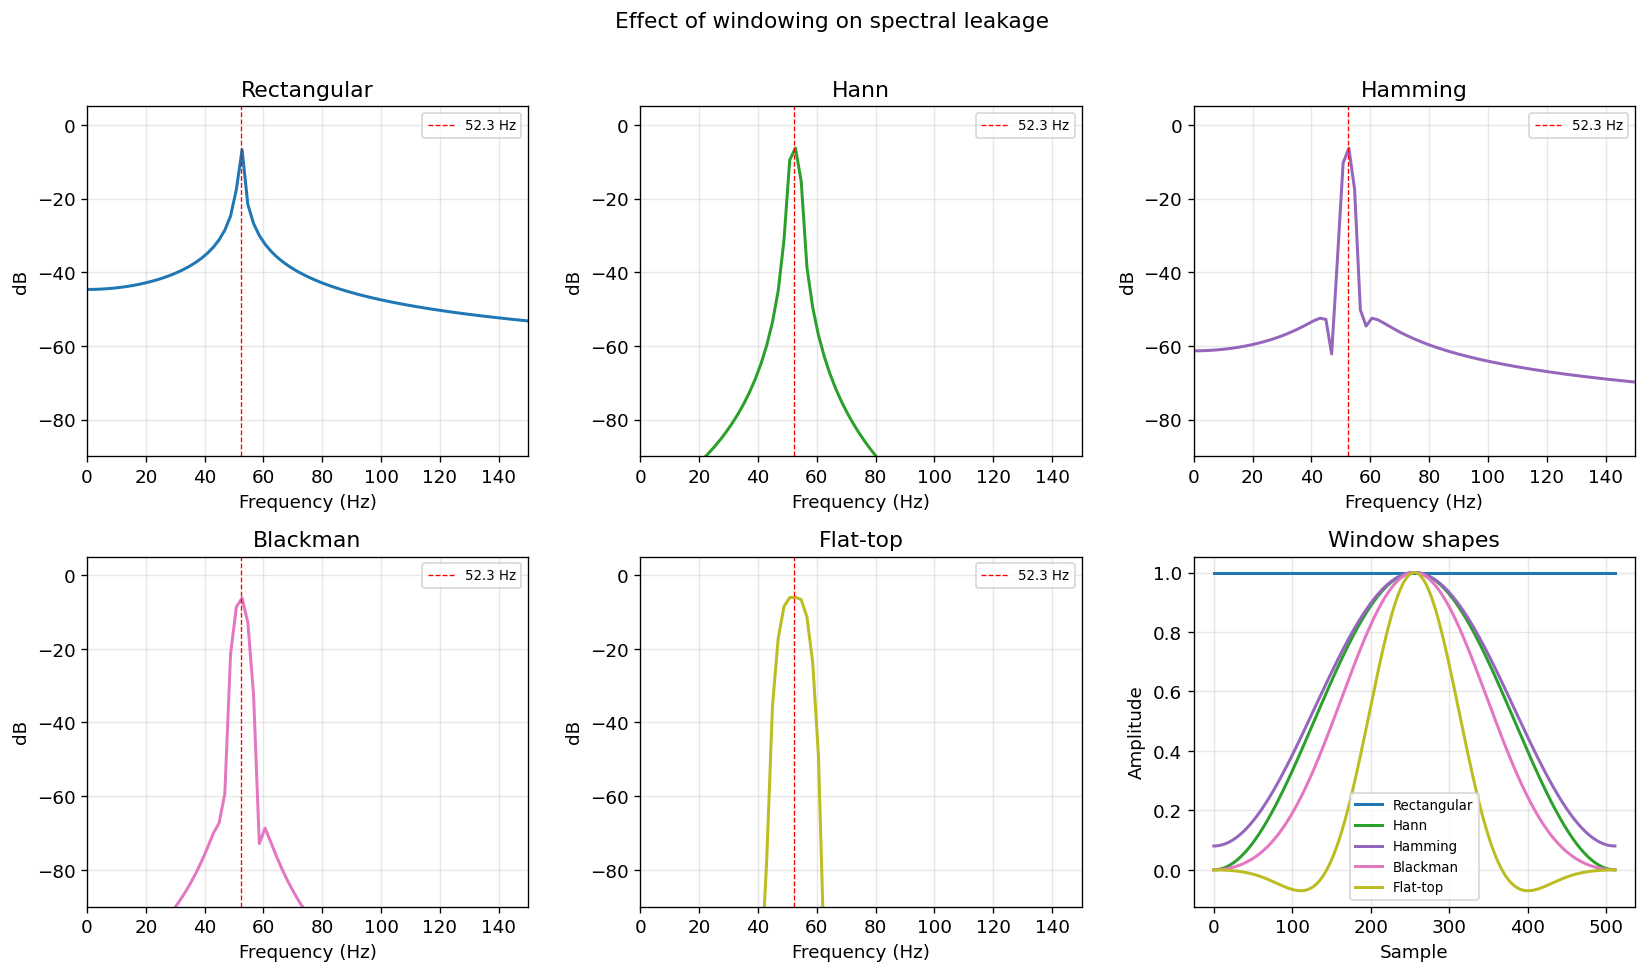

In [7]:
# ── 2b: Compare window functions on the leaking signal ───────────────────────

windows = {
    'Rectangular': np.ones(N),
    'Hann':        np.hanning(N),
    'Hamming':     np.hamming(N),
    'Blackman':    np.blackman(N),
    'Flat-top':    signal.windows.flattop(N),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

# Show each window
colors = plt.cm.tab10(np.linspace(0, 0.8, len(windows)))
for ax, (name, win), color in zip(axes_flat, windows.items(), colors):
    xw = x_frac * win
    correction = N / win.sum()          # coherent gain correction
    f_w, X_w = one_sided_mag(xw * correction, fs)

    ax.plot(f_w, 20*np.log10(np.maximum(X_w, 1e-10)), color=color)
    ax.set(title=name, xlabel='Frequency (Hz)', ylabel='dB',
           xlim=(0, 150), ylim=(-90, 5))
    ax.axvline(f_noninteger, color='red', ls='--', lw=0.8, label=f'{f_noninteger} Hz')
    ax.legend(fontsize=8)

# Last panel: window shapes
ax = axes_flat[-1]
for (name, win), color in zip(windows.items(), colors):
    ax.plot(win, label=name, color=color)
ax.set(title='Window shapes', xlabel='Sample', ylabel='Amplitude')
ax.legend(fontsize=8)

plt.suptitle('Effect of windowing on spectral leakage', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## 3. Vibration Analysis Automation Scenario

You are monitoring a cooling pump system. You have two types of sensors: a Piezoelectric Accelerometer (contact) and a Laser Displacement Sensor (non-contact). You suspect that at certain rotation speeds, the system enters a resonance frequency that could damage the motor.

**Task 1**
Create folder `Automation`.
Create a Python script `measure.py` that simulates a vibration measurement.
* Accept frequency (Hz) and sampling_rate (Hz) as command-line arguments.
* Generate a sine wave signal $y(t) = A \sin(2\pi f t)$ with some added Gaussian noise.
* If the frequency is $80$ Hz, double the amplitude (to simulate resonance).
* Save the time-series data (Time and Acceleration) into a CSV file named `data_f{freq}_s{rate}.csv`.

**Task 2** 
* Create a Bash script (`run_experiment.sh`) to test the effect of Aliasing.
* Run `measure.py` for a fixed frequency of 70 Hz.
* Vary the sampling_rate from 50 Hz to 200 Hz in steps of 25.
* Run these processes in parallel.

**Task 3** 
* Create a script `analyzeFFT.py` to post-process data.
* Read all generated CSV files and perform an FFT on each signal. Identify the peak frequency.
* Find which sampling rates resulted in an incorrect (aliased) frequency reading and which one correctly identified the 80 Hz resonance.

In [ ]:
%%writefile Automation/measure.py

In [12]:
%%writefile Automation/run_experiment.sh



Writing Automation/run_experiment.sh


In [13]:
%%writefile Automation/analyzeFFT.py


Writing Automation/analyzeFFT.py
